В этом блокноте фитируется $\epsilon(\omega)$ по коэффициентам отражения и пропускания графена разной толщины на полипропиленовой плёнке в зависимости от частоты

eps_air = 1.00027717 
n_PP = 1.498+1j*14e-4                                  
PolyPropylene film = 40 mkm
1 graphene layer = 35 nm

Котликов, 2021
1) задача определения параметров пленки по спектрам отражения и пропускания является типичной некорректной обратной задачей синтеза, неимеющей однозначного решения. Ее решение существенно зависит от наличия априорной информации о специфических особенностях исследуемых пленок и выбора метода решения.

Основная проблема - выбор числа точек регрессии, чтобы минимизировать случайную погрешность и изменение $\epsilon(\omega)$

Вопросы:
1) поглощение

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from scipy import optimize
import pandas as pd
import glob
import sys
sys.path.append(r'C:\Users\belco\Documents\Graphene\Graphene-films-plasmon-refractometry\lib')
from reflect import reflect_n


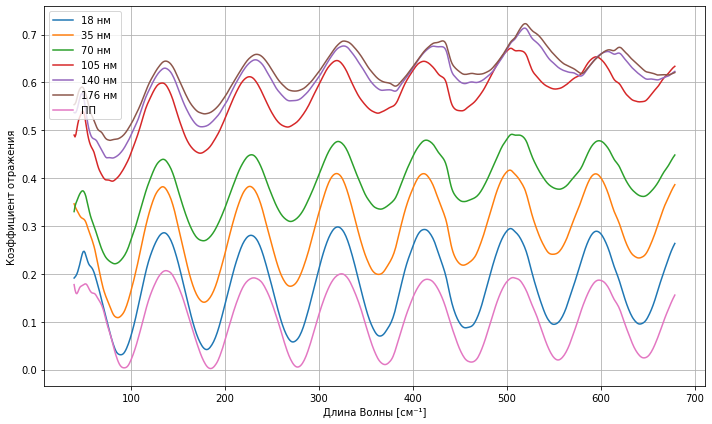

In [14]:
# Step 1: Load all 7 files into a list
file_paths = glob.glob(r"C:/Users/belco/Documents/Graphene/Data/Dispersion_PP_40/Ref_dis/*.dpt")  # Adjust the path and extension if needed

# Step 2: Initialize a plot
plt.figure(figsize=(10, 6))
labels = ['18 нм', '35 нм', '70 нм', '105 нм', '140 нм', '176 нм', 'ПП']

# Step 3: Loop through files and plot each
for i, file in enumerate(file_paths):
    data = pd.read_csv(file, header=None, sep='\t', decimal='.')  # Read file assuming no header
    _R_wavelength = data[0]  # First column: Wavelength [cm⁻¹]
    _reflectance = data[1]  # Second column: Reflectance R
    plt.plot(_R_wavelength, _reflectance, label=labels[i])  # Plot with label

# Step 4: Customize the plot
plt.xlabel("Длина Волны [см⁻¹]")
plt.ylabel("Коэффициент отражения")
#plt.title("Reflectance vs. Wavelength")
plt.legend()  # Add legend for dataset distinction
plt.grid(True)  # Optional: Add grid
plt.tight_layout()

# Step 5: Display the plot
plt.show()


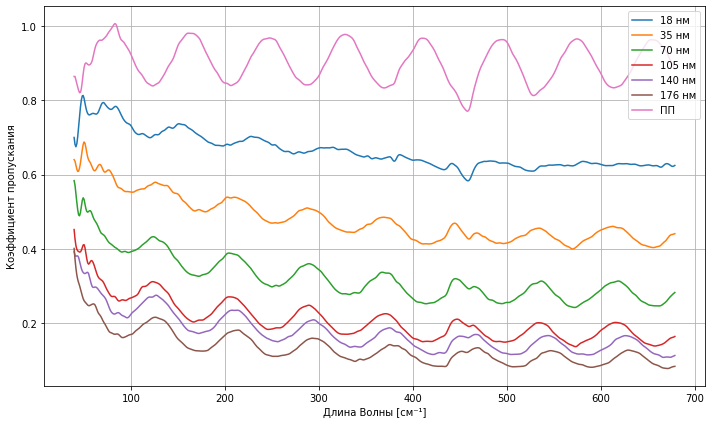

In [65]:
# Step 1: Load all 7 files into a list
file_paths = glob.glob(r"C:/Users/belco/Documents/Graphene/Data/Dispersion_PP_40/Transm_dis/*.dpt")  # Adjust the path and extension if needed

# Step 2: Initialize a plot
plt.figure(figsize=(10, 6))
labels = ['18 нм',  '35 нм', '70 нм', '105 нм', '140 нм', '176 нм', 'ПП']
_R_dict = {}
_T_dict = {}

# Step 3: Loop through files and plot each
for i, file in enumerate(file_paths):
    data = pd.read_csv(file, header=None, sep='\t', decimal='.')  # Read file assuming no header
    _T_wavelength = data[0]  # First column: Wavelength [cm⁻¹]
    _transmittance = data[1]  # Second column: Reflectance R
    plt.plot(_T_wavelength, _transmittance, label = labels[i])  # Plot with label

# Step 4: Customize the plot
plt.xlabel("Длина Волны [см⁻¹]")
plt.ylabel("Коэффициент пропускания")
#plt.title("Reflectance vs. Wavelength")
plt.legend()  # Add legend for dataset distinction
plt.grid(True)  # Optional: Add grid
plt.tight_layout()

# Step 5: Display the plot
plt.show()



In [84]:
# Define reflection and transmission functions

def rfl_gr_PP(teta, gr_thk, gr_re, gr_im, wl_rcpr, PP_thk, eps_PP):
    wl = 0.05/wl_rcpr
    eps_air = 1
    eps_re = np.array([eps_air.real, gr_re, eps_PP.real, eps_air.real])
    eps_im = np.array([eps_air.imag, gr_im, eps_PP.imag, eps_air.imag])
    thk_arr = np.array([gr_thk, PP_thk])
    R = 0.5*(reflect_n(teta = teta, thickness=thk_arr, eps_re=eps_re, eps_im=eps_im, wavelength=wl, polarization = 'p')+
               reflect_n(teta = teta, thickness=thk_arr, eps_re=eps_re, eps_im=eps_im, wavelength=wl, polarization = 's'))
    return R




In [85]:
# from functools import partial - не подходит для curve_fit
def fit_rfl(wl_rcpr, gr_re, gr_im):
    return rfl_gr_PP(teta=0, gr_thk=1e-10, gr_re=gr_re, gr_im=gr_im, wl_rcpr=wl_rcpr, PP_thk = 40e-6, eps_PP = 2.244+0.0042j)


In [86]:
@widgets.interact(teta = '0', gr_thk = '176e-9', gr_re = '-1', gr_im = '1')
def viz_rfl(teta, gr_thk, gr_re, gr_im):
    teta, gr_thk, gr_re, gr_im = (float(teta), float(gr_thk), float(gr_re), float(gr_im))
    wv_range = np.linspace(1, 700, 701)
    R = np.array([rfl_gr_PP(teta, gr_thk, gr_re, gr_im,  wv, 40e-6,  2.244+0.0042j) for wv in wv_range])
    plt.plot(wv_range, R)
    plt.show()

 
    

interactive(children=(Text(value='0', description='teta'), Text(value='176e-9', description='gr_thk'), Text(va…

[1. 1.] [[inf inf]
 [inf inf]]
[(486.0985251138, 0.119581759), (485.1340439131, 0.1133937538), (484.1695627125, 0.1072067618), (483.2050815119, 0.1010628268), (482.2406003113, 0.0949529931), (481.2761191107, 0.0888442695), (480.31163791, 0.0827196389), (479.3471567094, 0.076603964), (478.3826755088, 0.0705620497), (477.4181943082, 0.0646771267), (476.4537131075, 0.059012603), (475.4892319069, 0.0536020994), (474.5247507063, 0.048445411), (473.5602695057, 0.0435260311), (472.5957883051, 0.0388420932), (471.6313071044, 0.0344347656), (470.6668259038, 0.0303936303), (469.7023447032, 0.026828371), (468.7378635026, 0.0238205623), (467.7733823019, 0.021387456), (466.8089011013, 0.0194830671), (465.8444199007, 0.0180333927), (464.8799387001, 0.0169772934), (463.9154574994, 0.0162843931), (462.9509762988, 0.0159417111), (461.9864950982, 0.0159162749), (461.0220138976, 0.016181251), (460.057532697, 0.0166984368), (459.0930514963, 0.0174539238), (458.1285702957, 0.0184817463), (457.1640890951, 0

c:\Users\belco\miniconda3\envs\myenv\lib\site-packages\scipy\optimize\_minpack_py.py:881: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


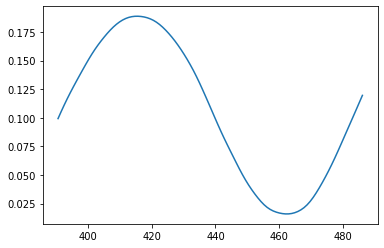

In [77]:
# fitting
_popt, _pcurve = optimize.curve_fit(fit_rfl, _R_wavelength[200:300], _reflectance[200:300])
print(_popt, _pcurve)
print(list(zip(_R_wavelength[200:300],_reflectance[200:300])))
plt.plot(_R_wavelength[200:300],_reflectance[200:300])

In [17]:
help(np.vectorize)

Help on class vectorize in module numpy:

class vectorize(builtins.object)
 |  vectorize(pyfunc, otypes=None, doc=None, excluded=None, cache=False, signature=None)
 |  
 |  vectorize(pyfunc, otypes=None, doc=None, excluded=None, cache=False,
 |            signature=None)
 |  
 |  Generalized function class.
 |  
 |  Define a vectorized function which takes a nested sequence of objects or
 |  numpy arrays as inputs and returns a single numpy array or a tuple of numpy
 |  arrays. The vectorized function evaluates `pyfunc` over successive tuples
 |  of the input arrays like the python map function, except it uses the
 |  broadcasting rules of numpy.
 |  
 |  The data type of the output of `vectorized` is determined by calling
 |  the function with the first element of the input.  This can be avoided
 |  by specifying the `otypes` argument.
 |  
 |  Parameters
 |  ----------
 |  pyfunc : callable
 |      A python function or method.
 |  otypes : str or list of dtypes, optional
 |      The 

Complex functions visualization

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb

# Define a complex-valued function f(x, y)
def complex_function(x, y):
    z = x + 1j * y  # Create a complex number z = x + iy
    return np.exp(-z)  # Example function

# Create a grid of x and y values
x = np.linspace(-2, 2, 500)  # X range
y = np.linspace(-2, 2, 500)  # Y range
X, Y = np.meshgrid(x, y)  # Create grid

# Compute the complex function on the grid
Z = complex_function(X, Y)

# Extract magnitude and phase
magnitude = np.abs(Z)  # Magnitude
phase = np.angle(Z)    # Phase (angle in radians)

# Normalize magnitude for brightness (value in HSV)
magnitude_normalized = magnitude / np.max(magnitude)

# Map phase (-π to π) to hue (0 to 1)
hue = (phase + np.pi) / (2 * np.pi)

# Create HSV image
hsv_image = np.zeros((*Z.shape, 3))  # HSV has 3 channels
hsv_image[..., 0] = hue              # Hue
hsv_image[..., 1] = 1.0              # Saturation (fully saturated)
hsv_image[..., 2] = magnitude_normalized  # Value (normalized magnitude)

# Convert HSV to RGB for plotting
rgb_image = hsv_to_rgb(hsv_image)

# Plot the color-domain map
plt.figure(figsize=(8, 8))
plt.imshow(rgb_image, extent=[x.min(), x.max(), y.min(), y.max()])
plt.title("Color-Domain Map of a Complex Function")
plt.xlabel("Re(z)")
plt.ylabel("Im(z)")
plt.colorbar(plt.cm.ScalarMappable(cmap="hsv"), label="Phase (Hue)")
plt.grid()
plt.tight_layout()
plt.show()
